In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
df = pd.read_csv("Zomato_Data.csv")

In [6]:
df

,name,online_order,rate,votes,location,rest_type,approx_cost
0,Jalsa,Yes,4.1,775,Banashankari,Casual Dining,800
1,Spice Elephant,Yes,4.1,787,Banashankari,Casual Dining,800
2,San Churro Cafe,Yes,3.8,918,Banashankari,"Cafe, Casual Dining",800
3,Addhuri Udupi Bhojana,No,3.7,88,Banashankari,Quick Bites,300
4,Grand Village,No,3.8,166,Basavanagudi,Casual Dining,600
...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,3.6,27,Whitefield,Bar,1500
51713,Vinod Bar And Restaurant,No,0.0,0,Whitefield,Bar,600
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,0.0,0,Whitefield,Bar,2000
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,4.3,236,"ITPL Main Road, Whitefield",Bar,2500


In [5]:
df = df.drop('Unnamed: 0',axis=1)

In [4]:
df = df.drop(['url','address','book_table','phone','dish_liked','cuisines','reviews_list','menu_item','listed_in(type)','listed_in(city)'],axis=1)

In [5]:
df = df.rename(columns={'approx_cost(for two people)':'approx_cost'})

In [6]:
df.dtypes

name            object
online_order    object
rate            object
votes            int64
location        object
rest_type       object
approx_cost     object
dtype: object

In [7]:
df = df.fillna(0)

In [9]:
df.approx_cost.unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', 0, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [10]:
df.approx_cost = df.approx_cost.replace('[,]','',regex=True).astype('int64')

In [11]:
df.rate.unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', 0, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [12]:
df.rate = df.rate.replace('-',0)
df.rate = df.rate.replace('NEW',0)
df.rate = df.rate.replace('[/5]','',regex=True).astype('float64')

In [13]:
df

,name,online_order,rate,votes,location,rest_type,approx_cost
0,Jalsa,Yes,4.1,775,Banashankari,Casual Dining,800
1,Spice Elephant,Yes,4.1,787,Banashankari,Casual Dining,800
2,San Churro Cafe,Yes,3.8,918,Banashankari,"Cafe, Casual Dining",800
3,Addhuri Udupi Bhojana,No,3.7,88,Banashankari,Quick Bites,300
4,Grand Village,No,3.8,166,Basavanagudi,Casual Dining,600
...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,3.6,27,Whitefield,Bar,1500
51713,Vinod Bar And Restaurant,No,0.0,0,Whitefield,Bar,600
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,0.0,0,Whitefield,Bar,2000
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,4.3,236,"ITPL Main Road, Whitefield",Bar,2500


In [14]:
df.groupby('location')['approx_cost'].mean().nlargest(15)

location
Sankey Road              2505.555556
Race Course Road         1309.352518
Lavelle Road             1293.100189
MG Road                  1125.490196
Infantry Road            1062.251656
Residency Road            964.888889
Langford Town             883.333333
St. Marks Road            871.306818
Cunningham Road           864.969450
Church Street             834.885764
Koramangala 3rd Block     778.472222
Ulsoor                    761.339198
Richmond Road             748.830049
Rajarajeshwari Nagar      725.000000
Sadashiv Nagar            717.460317
Name: approx_cost, dtype: float64

In [15]:
df.groupby('location')['rate'].sum().nlargest(15)

location
BTM                      13813.8
Koramangala 5th Block     9152.0
HSR                       7336.1
Indiranagar               7007.6
JP Nagar                  6258.5
Jayanagar                 6164.5
Whitefield                5667.4
Marathahalli              5040.0
Bannerghatta Road         4291.7
Koramangala 7th Block     4033.9
Koramangala 6th Block     4031.5
Brigade Road              3845.9
Bellandur                 3535.0
Koramangala 4th Block     3267.1
Ulsoor                    3157.3
Name: rate, dtype: float64

In [16]:
df.groupby('location')['votes'].sum().nlargest(15)

location
Koramangala 5th Block    2219506
Indiranagar              1196007
Koramangala 4th Block     685156
BTM                       619376
Church Street             594979
JP Nagar                  586593
Lavelle Road              506186
HSR                       499720
Koramangala 7th Block     495324
Jayanagar                 488080
Whitefield                466829
Koramangala 6th Block     465111
Marathahalli              445201
MG Road                   432111
Brigade Road              429620
Name: votes, dtype: int64

In [17]:
df.groupby('name')['approx_cost'].mean().nlargest(10)

name
Le Cirque Signature - The Leela Palace    6000.0
Royal Afghan - ITC Windsor                5000.0
Malties - Radisson Blu                    4500.0
La Brasserie - Le Meridien                4100.0
Alba - JW Marriott Bengaluru              4000.0
Dakshin - ITC Windsor                     4000.0
Dum Pukht Jolly Nabobs - ITC Windsor      4000.0
Edo Restaurant & Bar - ITC Gardenia       4000.0
Grill 99 - The Ritz-Carlton               4000.0
Jamavar - The Leela Palace                4000.0
Name: approx_cost, dtype: float64

In [18]:
df.groupby('name')['rate'].mean().nlargest(10)

name
Asia Kitchen By Mainland China                                                      4.900000
Byg Brewski Brewing Company                                                         4.900000
SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Spa Cuisine    4.900000
Punjab Grill                                                                        4.871429
Belgian Waffle Factory                                                              4.844828
Flechazo                                                                            4.800000
O.G. Variar & Sons                                                                  4.800000
The Pizza Bakery                                                                    4.800000
Barbecue by Punjab Grill                                                            4.750000
CTR                                                                                 4.750000
Name: rate, dtype: float64

In [19]:
df.groupby('name')['votes'].sum().nlargest(10)

name
Onesta                         347520
Truffles                       301059
Empire Restaurant              229808
Hammered                       180602
The Black Pearl                172122
Meghana Foods                  129557
Barbeque Nation                108425
Smally's Resto Cafe            102877
Byg Brewski Brewing Company     99531
Gilly's Restobar                98808
Name: votes, dtype: int64

In [20]:
df.groupby('rest_type')['approx_cost'].sum().nlargest(10)

rest_type
Casual Dining         8125300
Quick Bites           6046860
Cafe                  2286450
Casual Dining, Bar    1420550
Delivery              1120259
Fine Dining            936800
Bar                    869450
Takeaway, Delivery     790206
Dessert Parlor         746240
Lounge                 670850
Name: approx_cost, dtype: int64

In [21]:
df.groupby('rest_type')['rate'].mean().nlargest(10)

rest_type
Bar, Pub                       4.600000
Pub, Cafe                      4.595000
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Casual Dining, Irani Cafee     4.373333
Microbrewery, Pub              4.366667
Fine Dining, Microbrewery      4.300000
Microbrewery, Lounge           4.255556
Microbrewery, Bar              4.215385
Casual Dining, Microbrewery    4.206780
Name: rate, dtype: float64

In [22]:
df.groupby('rest_type')['votes'].sum().nlargest(10)

rest_type
Casual Dining          4549477
Quick Bites            1477467
Cafe                   1454783
Casual Dining, Bar     1225408
Casual Dining, Cafe     528752
Bar, Casual Dining      454532
Lounge                  407889
Pub                     405025
Pub, Microbrewery       350648
Cafe, Casual Dining     337753
Name: votes, dtype: int64

['Banashankari' 'Basavanagudi' 'Mysore Road' 'Jayanagar'
 'Kumaraswamy Layout' 'Rajarajeshwari Nagar' 'Vijay Nagar' 'Uttarahalli'
 'JP Nagar' 'South Bangalore' 'City Market' 'Nagarbhavi'
 'Bannerghatta Road' 'BTM' 'Kanakapura Road' 'Bommanahalli' 0
 'CV Raman Nagar' 'Electronic City' 'HSR' 'Marathahalli' 'Sarjapur Road'
 'Wilson Garden' 'Shanti Nagar' 'Koramangala 5th Block'
 'Koramangala 8th Block' 'Richmond Road' 'Koramangala 7th Block'
 'Jalahalli' 'Koramangala 4th Block' 'Bellandur' 'Whitefield'
 'East Bangalore' 'Old Airport Road' 'Indiranagar' 'Koramangala 1st Block'
 'Frazer Town' 'RT Nagar' 'MG Road' 'Brigade Road' 'Lavelle Road'
 'Church Street' 'Ulsoor' 'Residency Road' 'Shivajinagar' 'Infantry Road'
 'St. Marks Road' 'Cunningham Road' 'Race Course Road' 'Commercial Street'
 'Vasanth Nagar' 'HBR Layout' 'Domlur' 'Ejipura' 'Jeevan Bhima Nagar'
 'Old Madras Road' 'Malleshwaram' 'Seshadripuram' 'Kammanahalli'
 'Koramangala 6th Block' 'Majestic' 'Langford Town' 'Central Bangalore

Enter Location Name : Mysore Road


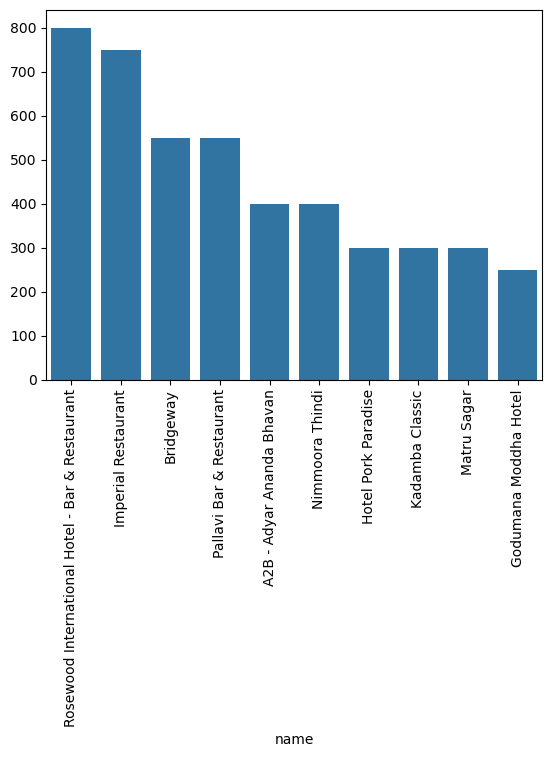

In [23]:
print(df.location.unique())
lo = input("Enter Location Name :")
rest = df[df.location == lo]
w = rest.groupby('name')['approx_cost'].mean().nlargest(10)

sb.barplot(x=w.index,y=w.values)
plt.xticks(rotation=90)
plt.show()